In [2]:
import logging, warnings
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr, ConstantInputWarning
from tqdm import tqdm
from umap import UMAP
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import importlib

from src.utils import iter_dataset_dirs, load_json
from src.plot_style import apply_plot_style
from src.visualization import plot_mts_corr_density, plot_spi_space_individual

apply_plot_style()
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
warnings.simplefilter("ignore", ConstantInputWarning)


In [3]:
def load_features_from_cache(cache_path):
    data = np.load(cache_path, allow_pickle=True)
    X = data["X"]
    mts_class = data["mts_class"] if "mts_class" in data.files else data["y"]
    dataset_paths = data["dataset_path"] if "dataset_path" in data.files else data["dataset_paths"]
    meta_df = pd.DataFrame({
        "mts_class": mts_class,
        "variant": data["variant"],
        "M": data["M"],
        "T": data["T"],
        "dataset_path": dataset_paths,
        "instance": data["instance"] if "instance" in data.files else None,
    })
    spi_order = list(data.get("spi_order", []))
    pairs = list(data.get("pairs", []))
    return X, meta_df, spi_order, pairs


In [ ]:
X, meta_df, spi_order, pairs = load_features_from_cache("analysis/feature_cache/data-case_1_master_signal_pearson.npz")
# X, meta_df, spi_order, pairs = load_features_from_cache("analysis/feature_cache/data-case_1_master_signal_spearman.npz")
# X, meta_df, spi_order, pairs = load_features_from_cache("analysis/feature_cache/data-case_1_master_signal_mi.npz")


In [5]:
eps = 1e-8              # “near zero” cutoff; relax to 1e-6 if you want
dom_thresh = 0.99       # flag features that are near zero in ≥99% of datasets

abs_X = np.abs(X)
frac_near_zero = (abs_X < eps).mean(axis=0)      # per-column fraction near zero
all_near_zero = frac_near_zero == 1.0            # exactly zero (within eps) everywhere
dom_near_zero = frac_near_zero >= dom_thresh     # almost always zero

summary = pd.DataFrame({
    "feature_idx": np.arange(X.shape[1]),
    "min": X.min(axis=0),
    "max": X.max(axis=0),
    "frac_near_zero": frac_near_zero,
    "all_near_zero": all_near_zero,
    "dom_near_zero": dom_near_zero,
})
summary_near_zero = summary[summary["dom_near_zero"]].sort_values("frac_near_zero", ascending=False)
summary_near_zero.head()

,feature_idx,min,max,frac_near_zero,all_near_zero,dom_near_zero


In [6]:
# Example if pairs aligns 1:1 with columns
labels = [f"{a} vs {b}" for a, b in pairs]  # adjust to your actual mapping
summary["label"] = labels
summary_near_zero = summary[summary["dom_near_zero"]].sort_values("frac_near_zero", ascending=False)
summary_near_zero[["feature_idx", "label", "frac_near_zero", "min", "max"]].head(20)


,feature_idx,label,frac_near_zero,min,max


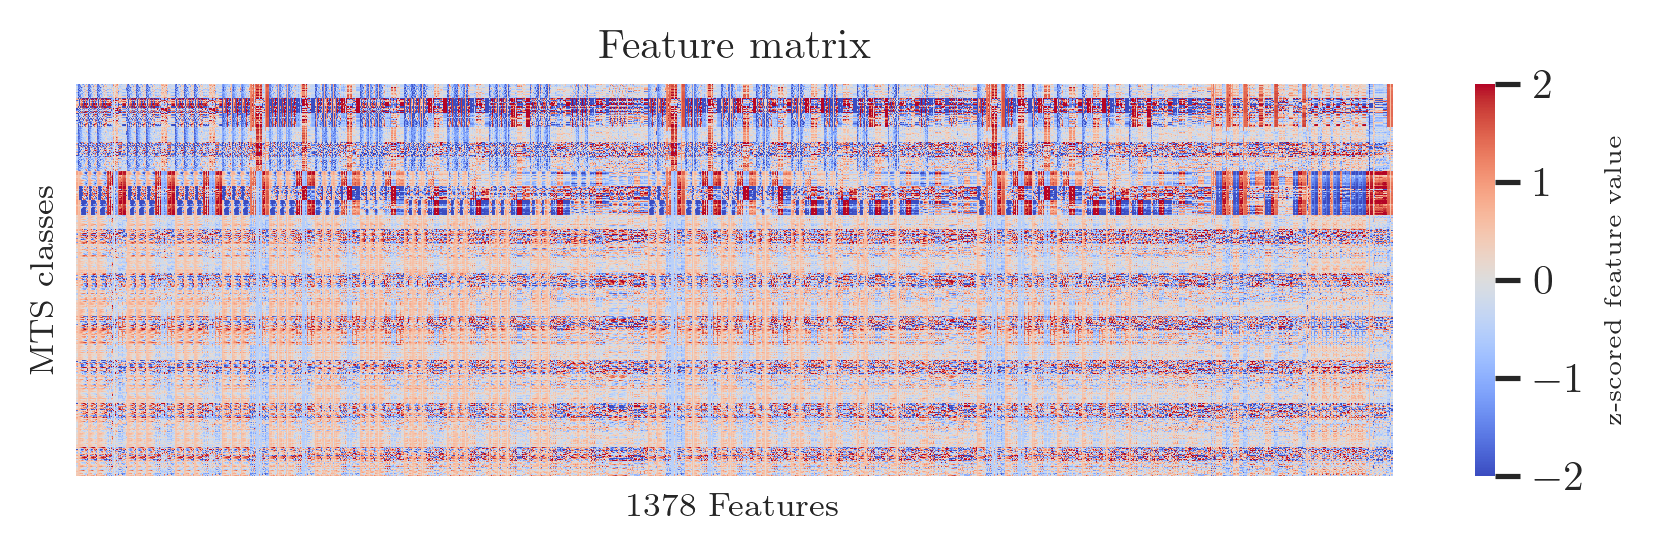

In [7]:
selected_classes = ["set1_a0_b0_c1p0_g_affine_alpha0p8_beta0", 
                    "set1_a0_b0_c1p0_g_sigmoid_beta8p0", 
                    "set2a_a0p4_b0_c0p6_g_affine_alpha0p8_beta0",
                    "set2a_a0p6_b0_c1p0_g_sigmoid_beta4p0",
                    ]  # specify desired classes or leave empty for all

selected_classes = []  # specify desired classes or leave empty for all

if selected_classes:
    noise_mask = meta_df["mts_class"].isin(selected_classes)
    X_selected = X[noise_mask]
    meta_selected = meta_df[noise_mask]
else:
    X_selected = X
    meta_selected = meta_df

# Z-normalize each feature (column) across the selected noise datasets
col_means = X_selected.mean(axis=0)
col_stds = X_selected.std(axis=0)
Xz = (X_selected - col_means) / (col_stds + 1e-9)  # avoid div-by-zero


fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
sns.heatmap(Xz, cmap="coolwarm", cbar=True, ax=ax, vmin=-2, vmax=2)  #cbar_kws={"shrink": 0.8},
ax.collections[0].colorbar.set_label("z-scored feature value", fontsize=6)
ax.set_xlabel(f"{Xz.shape[1]} Features", fontsize=8)
ax.set_ylabel("MTS classes", fontsize=8)
ax.set_xticklabels(""), ax.set_yticklabels("")
ax.set_xticks([]), ax.set_yticks([])
ax.set_title(f"Feature matrix", fontsize=10)
plt.tight_layout()
plt.show()

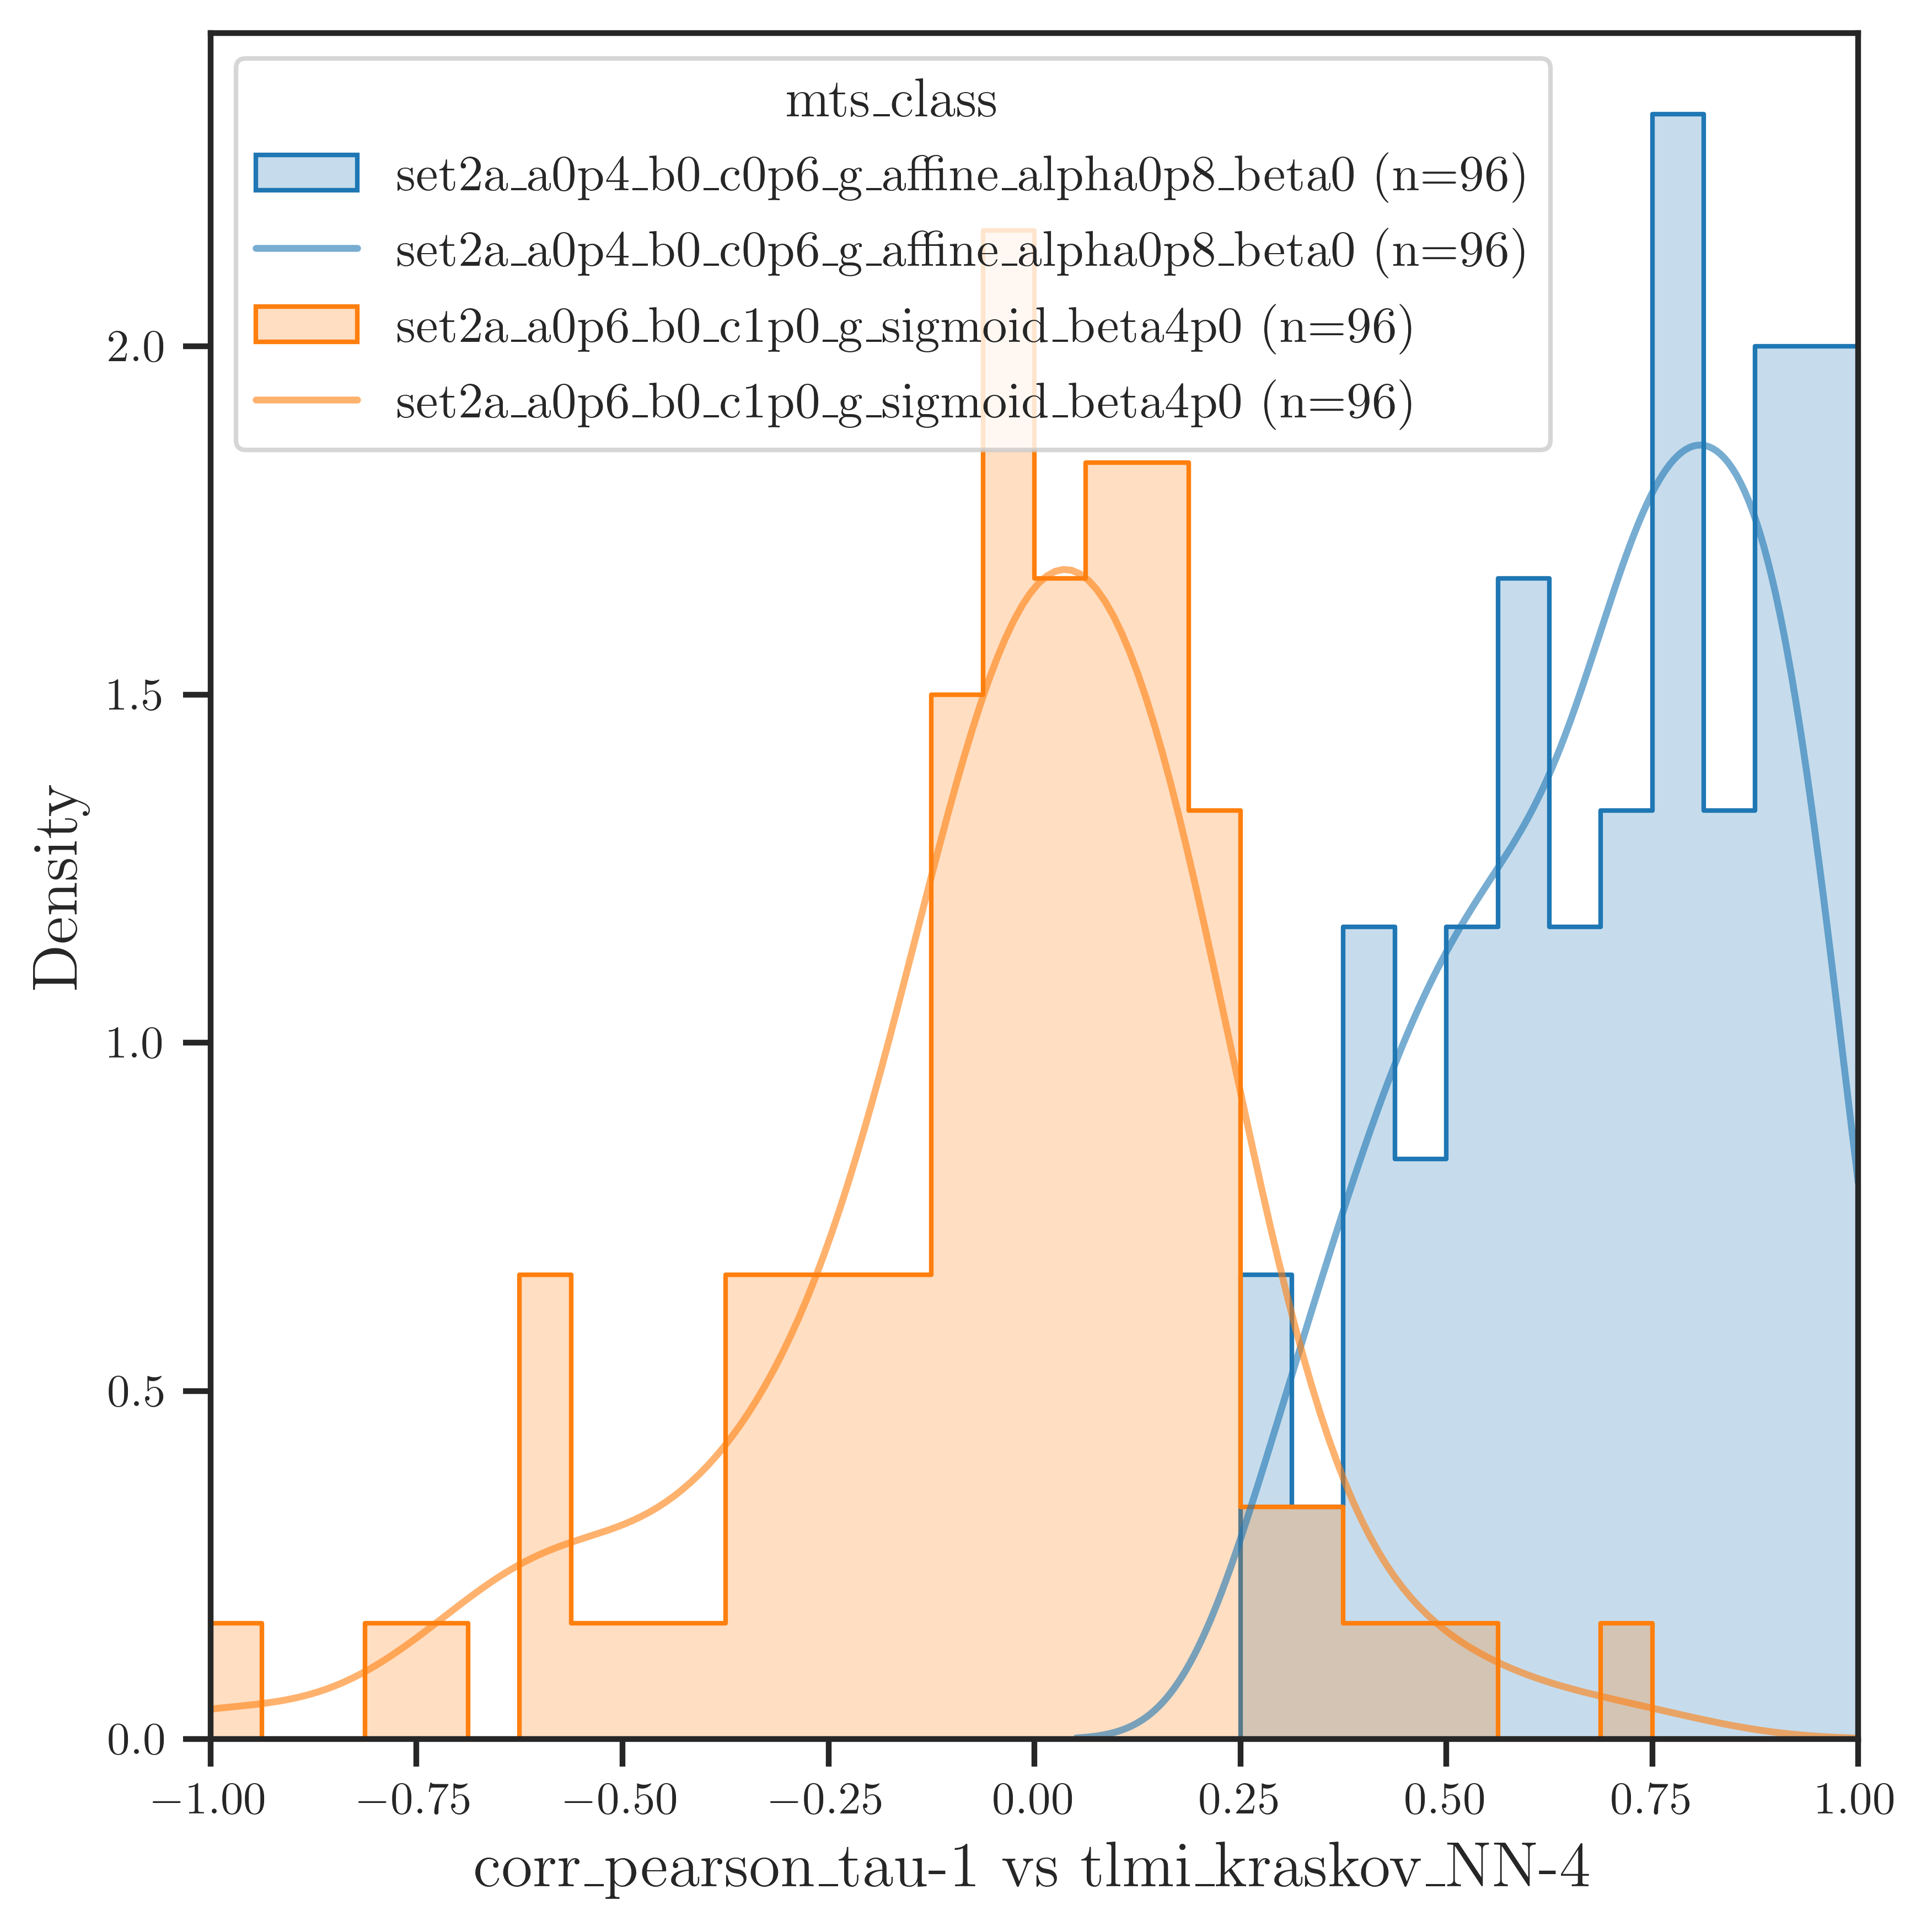

In [8]:
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_spi_space_individual, plot_mts_corr_density_dir, plot_mts_corr_density


plot_mts_corr_density(
    "data/case_i_rrho_mi/set2a_a0p4_b0_c0p6_g_affine_alpha0p8_beta0", "data/case_i_rrho_mi/set2a_a0p6_b0_c1p0_g_sigmoid_beta4p0",
    # ["corr_pearson_tau-1", "corr_spearman_tau-1"],
    # ["corr_spearman_tau-1", "mi_gaussian"],
    ["corr_pearson_tau-1", "tlmi_kraskov_NN-4"],
    # ["corr_pearson_tau-1", "tlmi_gaussian"],
    bw_adjust=1.0,  # optional KDE bandwidth tweak
    show_hist=True,
    bins=32
)

# plot_mts_corr_density(
#     "data/case_i_rrho_mi/set1_a0_b0_c1p0_g_affine_alpha0p8_beta0", "data/case_i_rrho_mi/set1_a0_b0_c1p0_g_sigmoid_beta8p0",
#     # ["corr_pearson_tau-1", "corr_spearman_tau-1"],
#     # ["corr_spearman_tau-1", "mi_gaussian"],
#     # ["corr_pearson_tau-1", "tlmi_gaussian"],
#     ["corr_spearman_tau-1", "tlmi_kraskov_NN-4"],
#     bw_adjust=1.0,  # optional KDE bandwidth tweak
#     show_hist=True,
#     bins=32
# )

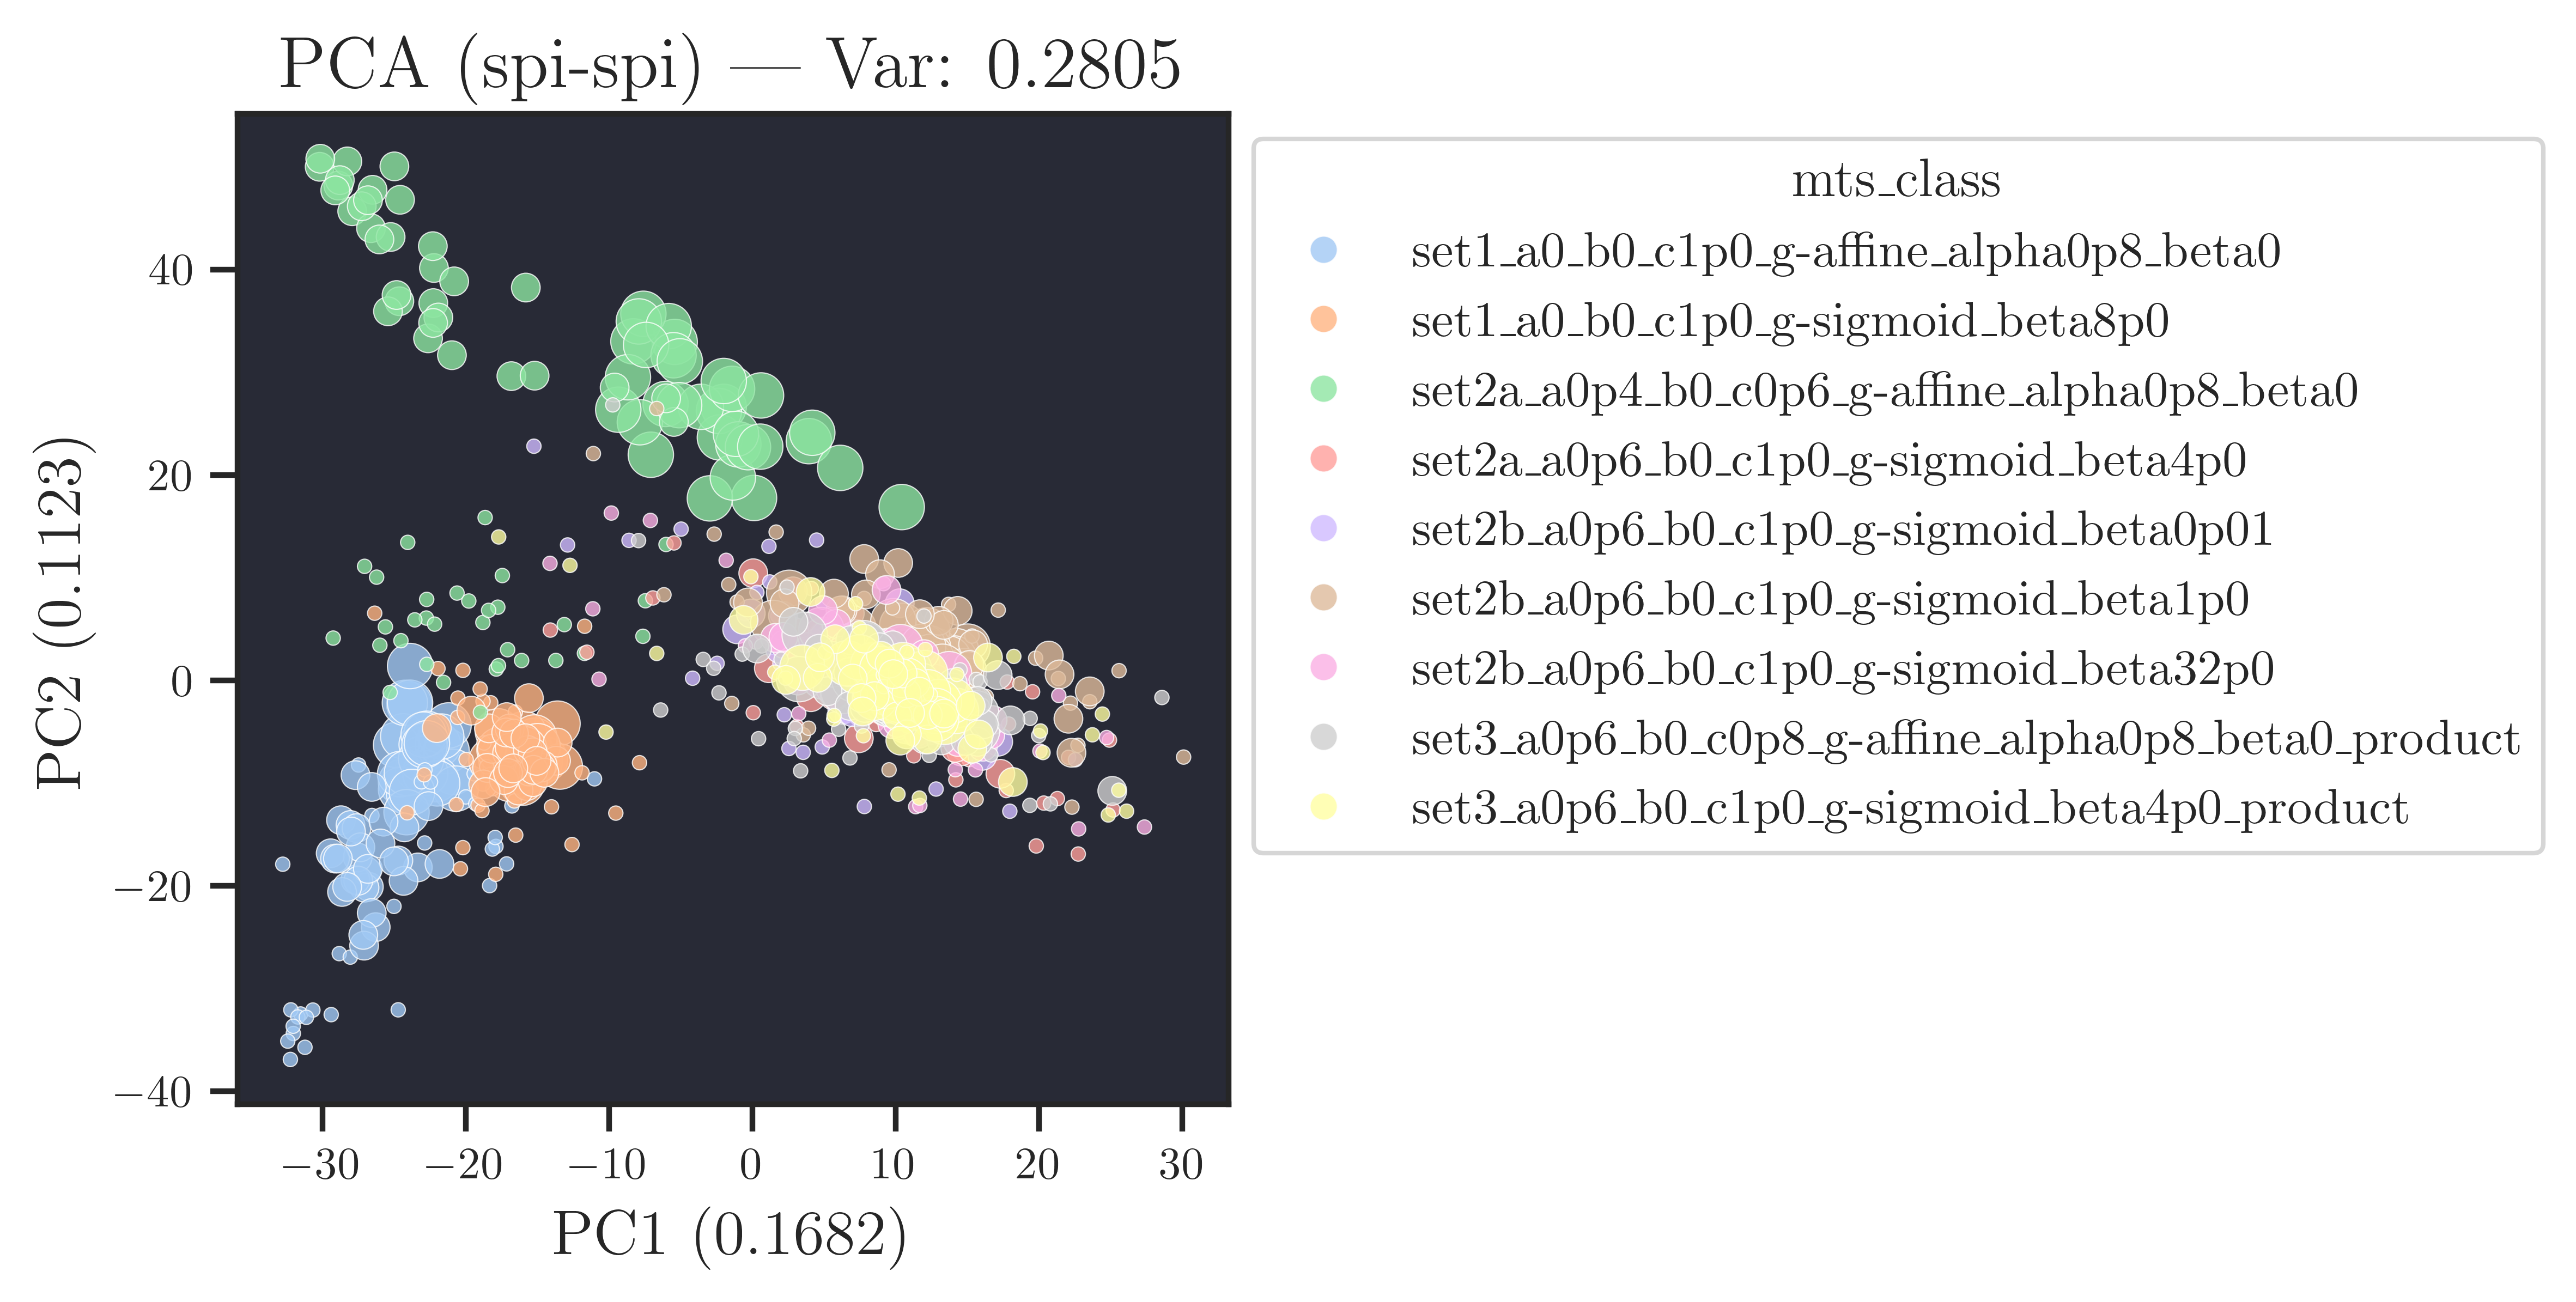

/Users/wedi0306/Library/CloudStorage/OneDrive-Personal/Desktop/2025USYD/USYD/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.55, n_jobs=1, n_neighbors=6, random_state=0, verbose=True)
Wed Feb  4 11:37:50 2026 Construct fuzzy simplicial set
Wed Feb  4 11:37:50 2026 Finding Nearest Neighbors
Wed Feb  4 11:37:50 2026 Finished Nearest Neighbor Search
Wed Feb  4 11:37:50 2026 Construct embedding


Epochs completed:  28%| ██▊        139/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs


Epochs completed:  56%| █████▌     278/500 [00:00]

	completed  300  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:00]


	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Feb  4 11:37:51 2026 Finished embedding


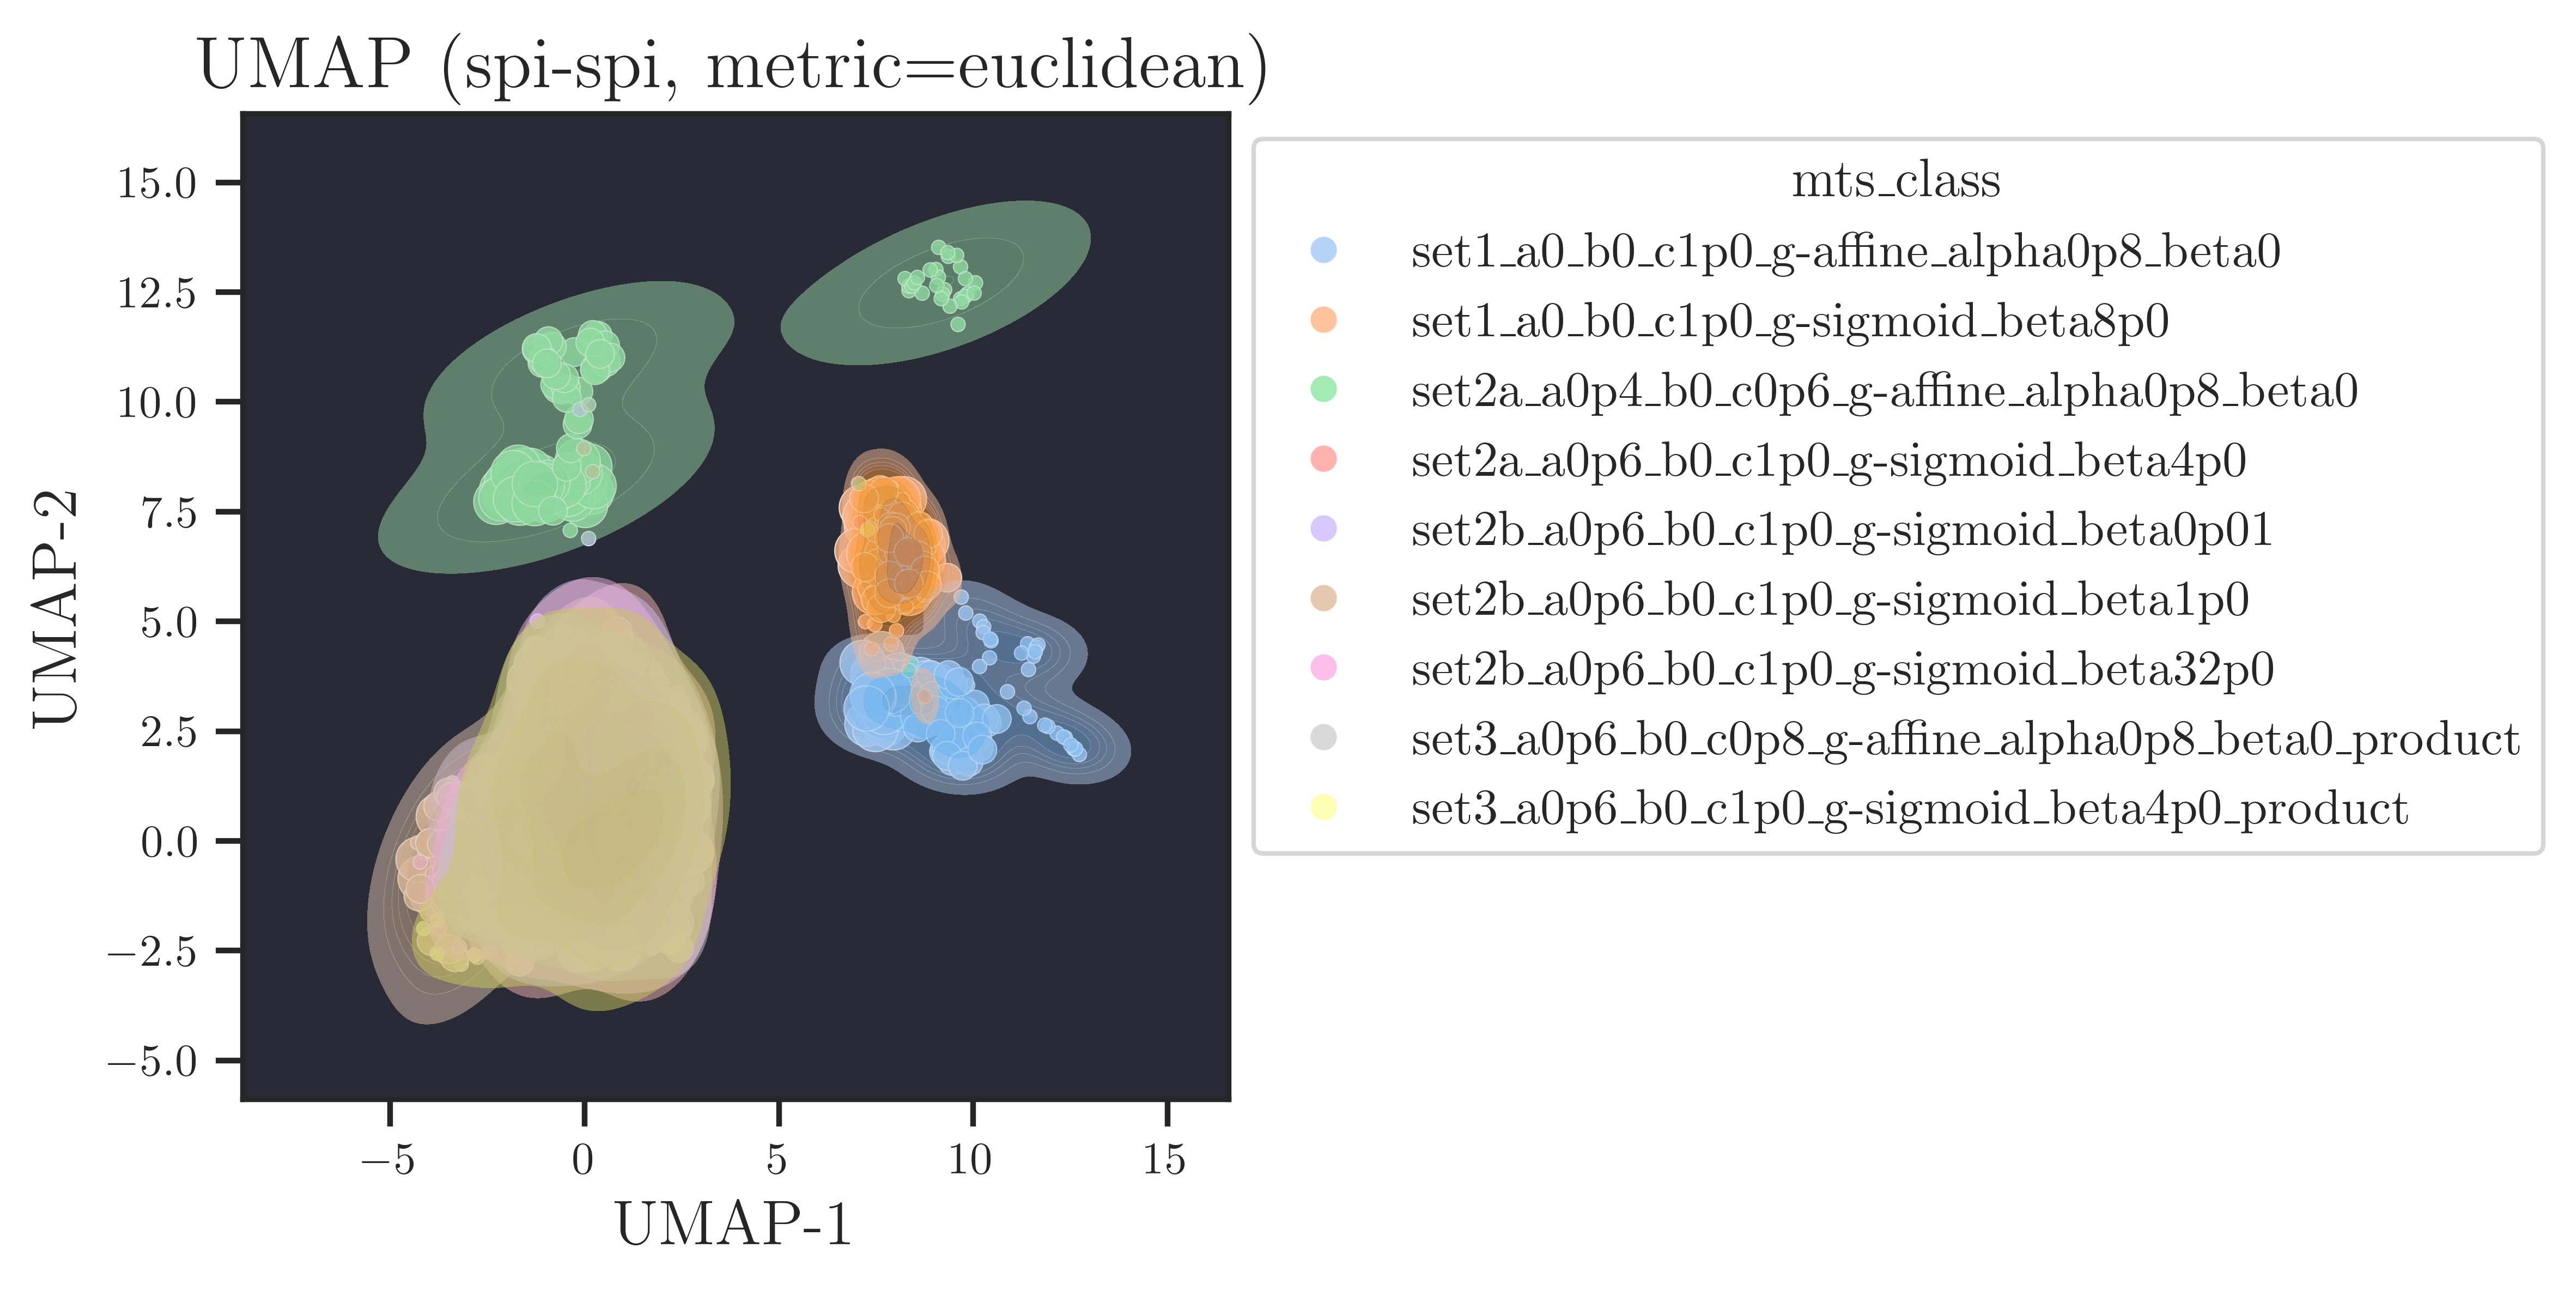

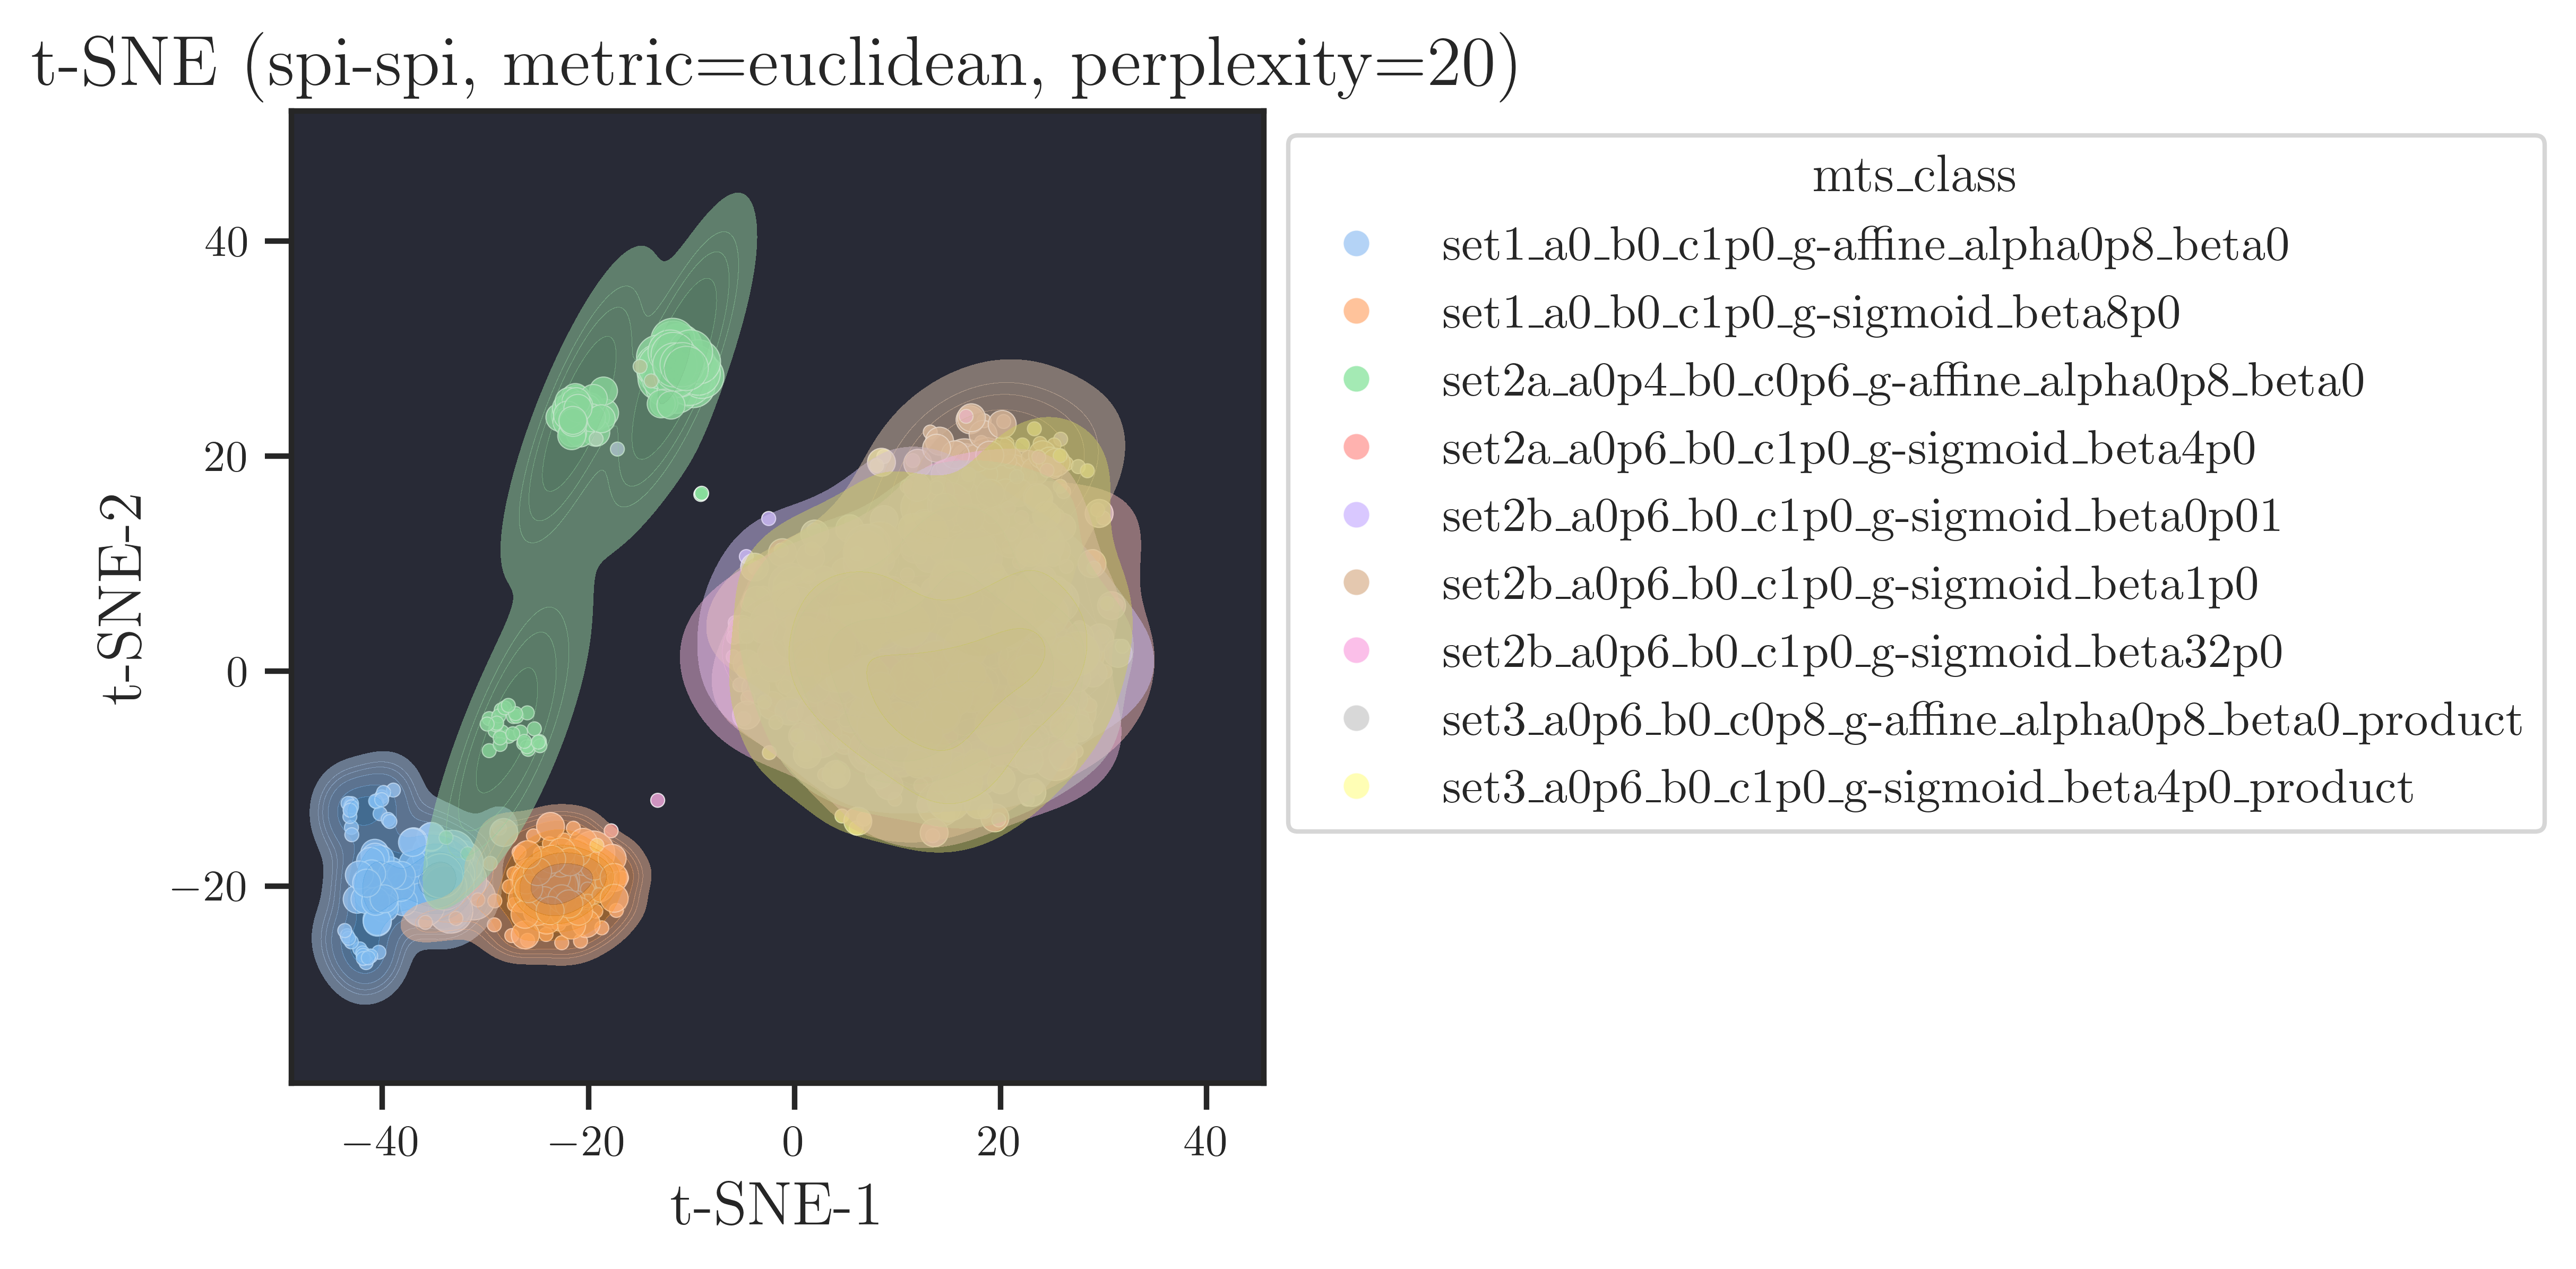

In [19]:
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_pca, plot_umap, plot_tsne, plot_spi_space_individual, plot_spi_space_recursive

# Common kwargs for all plots
common_kwargs = dict(
    feature_space=f"spi-spi",
    hue="mts_class",
    size_col="M",
    sizes=(10, 100),
    random_state=0,
    facecolor="#282a36" 
)


# embedding_pca = plot_pca(X, meta_df, **common_kwargs)
# embedding_umap = plot_umap(X, meta_df, metric="euclidean", n_neighbors=6, min_dist=0.55,**common_kwargs)
# embedding_tsne = plot_tsne(X, meta_df, metric="euclidean", perplexity=5, **common_kwargs)

embedding_pca = plot_pca(Xz, meta_selected, **common_kwargs)
embedding_umap = plot_umap(Xz, meta_selected, metric="euclidean", n_neighbors=6, min_dist=0.55,**common_kwargs)
embedding_tsne = plot_tsne(Xz, meta_selected, metric="euclidean", perplexity=20, **common_kwargs)

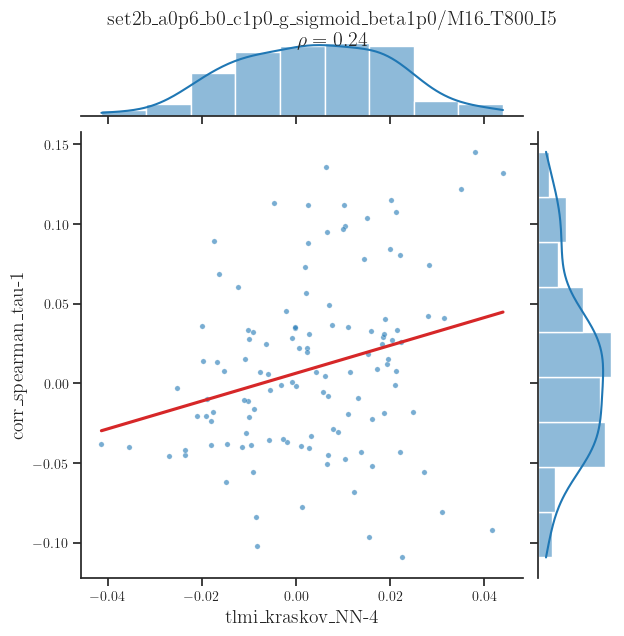

In [18]:
plot_spi_space_individual("data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta1p0/M16_T800_I5", 
                          ["tlmi_kraskov_NN-4", "corr_spearman_tau-1"])

In [20]:
plot_spi_space_recursive(dataset_path="data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01",
                         spis=["mi_kraskov_NN-4", "corr_pearson_tau-1"],
                         formats=["png"],)

[INFO] Saved 96 plots to data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4_corr_pearson_tau-1


[PosixPath('data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4_corr_pearson_tau-1/M16_T1600_I0.png'),
 PosixPath('data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4_corr_pearson_tau-1/M16_T1600_I1.png'),
 PosixPath('data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4_corr_pearson_tau-1/M16_T1600_I2.png'),
 PosixPath('data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4_corr_pearson_tau-1/M16_T1600_I3.png'),
 PosixPath('data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4_corr_pearson_tau-1/M16_T1600_I4.png'),
 PosixPath('data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4_corr_pearson_tau-1/M16_T1600_I5.png'),
 PosixPath('data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4_corr_pearson_tau-1/M16_T1600_I6.png'),
 PosixPath('data/case_i_rrho_mi/set2b_a0p6_b0_c1p0_g_sigmoid_beta0p01/plot_mi_kraskov_NN-4